# Advanced Natural Language Processing  
## Assignment 1: Human vs Machine Text Classification  

**Student Name:** Gayatri Kannan Padma  
**Student ID:** 48628948  

---

## Introduction

This assignment develops a complete NLP pipeline to classify text as either human-generated or machine-generated.

The project covers:
- collecting and preparing datasets,
- performing exploratory data analysis,
- applying NLP feature-extraction techniques,
- building statistical and deep learning classification models,
- and evaluating model performance.

The goal is to simulate real-world AI detection systems and understand the challenges involved in distinguishing human-written text from machine-generated content.

In [2]:
!pip install -q seaborn
!pip install -q -U "transformers[torch]" "accelerate>=0.26.0"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mitmproxy 12.2.0 requires h11<=0.16.0,>=0.16.0, but you have h11 0.14.0 which is incompatible.
streamlit 1.32.0 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


## Import Libraries

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import uuid, warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP preprocessing
import re, string

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

# PyTorch / HuggingFace
import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 2. Data Collection

This section describes the datasets used for the classification task and how the final hybrid dataset was assembled.

### 2.1 Primary Dataset: Human vs Machine Text (`shuffled_data.csv`)

The primary dataset is `shuffled_data.csv`, containing 20,000 labelled text samples for binary classification of human-generated and machine-generated text. It is associated with a scientific study published in *Nature Scientific Reports*.

Labels:
- `0` → Human-generated text  
- `1` → Machine-generated text  

The dataset was selected for its large size, balanced class distribution, and direct relevance to the task.

**Reference:** https://www.nature.com/articles/s41598-025-27377-z

In [7]:
# Load primary public dataset
# Update this path to where shuffled_data.csv is stored on your machine
df_public = pd.read_csv("shuffled_data.csv")

print("Public dataset shape:", df_public.shape)
df_public.head()

Public dataset shape: (20000, 2)


,Data,Labels
0,"When fish die near the poles, their bodies typ...",1
1,Exceptions are typically indicated by sett...,0
2,"Unihemispheric slow wave sleep. Dolphins, whal...",0
3,While texting did not become popular until the...,0
4,Fonts are typically created by designers or ty...,1


### 2.2 Hybrid Dataset Construction

To enhance dataset diversity and improve generalisation, a custom matched dataset was also created:

- **Human-written text** collected from Wikipedia passages.
- **Machine-generated text** produced by prompting a large language model to rewrite those same Wikipedia passages.

This *matched* design means each human text has a corresponding machine-generated counterpart on the same topic, ensuring the model learns stylistic differences rather than topic differences.

The final combined dataset draws from:
- `shuffled_data.csv` (primary public dataset)
- `my_human_texts.csv` (custom human texts)
- `machine_texts.csv` (custom machine texts)

In [9]:
# Load custom matched datasets
df_human = pd.read_csv("my_human_texts.csv")
df_machine = pd.read_csv("machine_texts.csv")

print("Human dataset shape:", df_human.shape)
display(df_human.head())

print("Machine dataset shape:", df_machine.shape)
display(df_machine.head())

Human dataset shape: (1934, 2)


,text,label
0,The 1981 Temple Owls football team was an Amer...,0
1,Wilms voyaged to South Africa on the same boat...,0
2,In 1896 he returned to Germany with an extensi...,0
3,Wilms was later appointed as an assistant in t...,0
4,"The Rodeo Soccer Club, also known as Rodeo SC,...",0


Machine dataset shape: (1934, 2)


,text,label
0,"Overall, The 1981 Temple Owls football team wa...",1
1,"In summary, Wilms voyaged to South Africa on t...",1
2,"More specifically, In 1896 he returned to Germ...",1
3,"From an analytical perspective, Wilms was late...",1
4,"In practical terms, The Rodeo Soccer Club, als...",1


### 2.3 Standardise Schema

All three datasets are standardised to a common schema:
- `text` → the text content
- `label` → `0` = human-generated, `1` = machine-generated

In [11]:
# Standardise column names
df_public = df_public.rename(columns={"Data": "text", "Labels": "label"})

df_public = df_public[["text", "label"]]
df_human  = df_human[["text", "label"]]
df_machine = df_machine[["text", "label"]]

print("Column check — public:", df_public.columns.tolist())
print("Column check — human: ", df_human.columns.tolist())
print("Column check — machine:", df_machine.columns.tolist())

Column check — public: ['text', 'label']
Column check — human:  ['text', 'label']
Column check — machine: ['text', 'label']


### 2.4 Data Cleaning and Pair-Aware Splitting

The following cleaning steps are applied to all datasets:
- remove missing values
- convert to string and strip whitespace
- remove empty and duplicate rows

A **pair-aware split** is then applied to the custom matched data so that corresponding human/machine text pairs always end up in the same partition (train, val, or test). This prevents data leakage and ensures a more realistic evaluation scenario.

The public dataset is split using stratified sampling to maintain the 50/50 class balance across all partitions.

In [13]:
def clean_dataframe(df):
    df = df.copy()
    df = df.dropna(subset=["text", "label"])
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    df["label"] = df["label"].astype(int)
    return df

df_public  = clean_dataframe(df_public)
df_human   = clean_dataframe(df_human)
df_machine = clean_dataframe(df_machine)

print("Cleaned public dataset shape:", df_public.shape)
print("Cleaned human dataset shape: ", df_human.shape)
print("Cleaned machine dataset shape:", df_machine.shape)

print("\nPublic label counts:")
print(df_public["label"].value_counts())

Cleaned public dataset shape: (19866, 2)
Cleaned human dataset shape:  (1934, 2)
Cleaned machine dataset shape: (1934, 2)

Public label counts:
label
1    9947
0    9919
Name: count, dtype: int64


In [14]:
# Assign pair IDs for leakage-free splitting
assert len(df_human) == len(df_machine), "Matched datasets must be the same size."
df_human   = df_human.copy();  df_human["pair_id"]   = range(len(df_human))
df_machine = df_machine.copy(); df_machine["pair_id"] = range(len(df_machine))

pair_ids = np.arange(len(df_human))

# 70 / 15 / 15 split on pair IDs
train_pairs, temp_pairs = train_test_split(pair_ids, test_size=0.30, random_state=42)
val_pairs,   test_pairs = train_test_split(temp_pairs, test_size=0.50, random_state=42)

def make_matched_split(ids):
    return pd.concat([
        df_human[df_human["pair_id"].isin(ids)],
        df_machine[df_machine["pair_id"].isin(ids)]
    ], ignore_index=True).drop(columns=["pair_id"])

matched_train = make_matched_split(train_pairs)
matched_val   = make_matched_split(val_pairs)
matched_test  = make_matched_split(test_pairs)

# Stratified split for public dataset
public_train, public_temp = train_test_split(df_public, test_size=0.30, random_state=42, stratify=df_public["label"])
public_val,   public_test = train_test_split(public_temp, test_size=0.50, random_state=42, stratify=public_temp["label"])

# Merge and shuffle
train_df = pd.concat([public_train, matched_train], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
val_df   = pd.concat([public_val,   matched_val],   ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = pd.concat([public_test,  matched_test],  ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final val shape:  ", val_df.shape)
print("Final test shape: ", test_df.shape)

Final train shape: (16612, 2)
Final val shape:   (3560, 2)
Final test shape:  (3562, 2)


In [15]:
# Sanity checks
print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True).round(4), "\n")

# No overlap across splits
train_t, val_t, test_t = set(train_df["text"]), set(val_df["text"]), set(test_df["text"])
print("Train ∩ Val overlap: ", len(train_t & val_t))
print("Train ∩ Test overlap:", len(train_t & test_t))
print("Val ∩ Test overlap:  ", len(val_t & test_t))

# Missing values
print("\nMissing values in train:", train_df.isnull().sum().sum())

Train label distribution:
label
1    0.5006
0    0.4994
Name: proportion, dtype: float64 

Train ∩ Val overlap:  0
Train ∩ Test overlap: 0
Val ∩ Test overlap:   0

Missing values in train: 0


In [16]:
# Save final splits
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv",   index=False)
test_df.to_csv("test_dataset.csv",  index=False)
print("Datasets saved: train_dataset.csv, val_dataset.csv, test_dataset.csv")

Datasets saved: train_dataset.csv, val_dataset.csv, test_dataset.csv


In [17]:
# Dataset summary table
summary_df = pd.DataFrame({
    "Split":      ["Train", "Validation", "Test"],
    "Total Rows": [len(train_df), len(val_df), len(test_df)],
    "Human (0)":  [(train_df["label"]==0).sum(), (val_df["label"]==0).sum(), (test_df["label"]==0).sum()],
    "Machine (1)":[(train_df["label"]==1).sum(), (val_df["label"]==1).sum(), (test_df["label"]==1).sum()]
})
display(summary_df)

,Split,Total Rows,Human (0),Machine (1)
0,Train,16612,8296,8316
1,Validation,3560,1778,1782
2,Test,3562,1779,1783


### 2.5 Exploratory Data Analysis

Visualising class distribution and text-length statistics to confirm balance and understand the data.

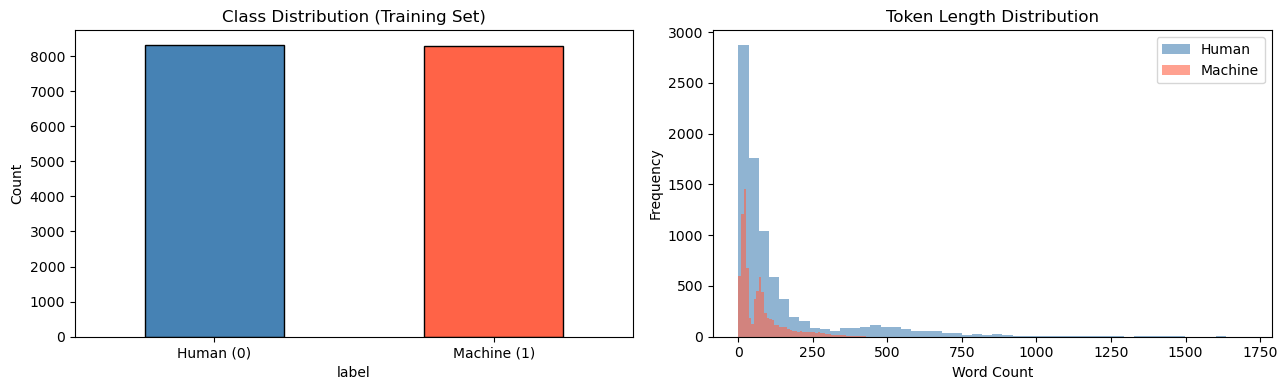

Median token length — Human:  58.0
Median token length — Machine: 47.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
train_df["label"].value_counts().plot(kind="bar", ax=axes[0],
    color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Class Distribution (Training Set)")
axes[0].set_xticklabels(["Human (0)", "Machine (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Text length distribution
train_df["text_len"] = train_df["text"].str.split().str.len()
for label, colour, name in [(0, "steelblue", "Human"), (1, "tomato", "Machine")]:
    subset = train_df[train_df["label"] == label]["text_len"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=colour, label=name)
axes[1].set_title("Token Length Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Median token length — Human: ", train_df[train_df["label"]==0]["text_len"].median())
print("Median token length — Machine:", train_df[train_df["label"]==1]["text_len"].median())
train_df.drop(columns=["text_len"], inplace=True)

# 3. Data Analysis

This section extracts features from the text, trains statistical classifiers, compares settings, and analyses which features best distinguish human from machine-generated text.

In [21]:
# Reload splits for analysis section
train_df = pd.read_csv("train_dataset.csv")
val_df   = pd.read_csv("val_dataset.csv")
test_df  = pd.read_csv("test_dataset.csv")

X_train, y_train = train_df["text"], train_df["label"]
X_val,   y_val   = val_df["text"],   val_df["label"]
X_test,  y_test  = test_df["text"],  test_df["label"]

## 3.1 Experiment 1 — TF-IDF Unigram + Logistic Regression

TF-IDF (Term Frequency–Inverse Document Frequency) encodes each text as a weighted vector of its most informative words. The unigram setting captures individual word importance.

In [23]:
tfidf_uni = TfidfVectorizer(max_features=10000, ngram_range=(1,1), stop_words="english")
X_train_uni = tfidf_uni.fit_transform(X_train)
X_val_uni   = tfidf_uni.transform(X_val)
X_test_uni  = tfidf_uni.transform(X_test)

lr_uni = LogisticRegression(max_iter=1000, random_state=42)
lr_uni.fit(X_train_uni, y_train)

val_pred_uni = lr_uni.predict(X_val_uni)
print("Validation Accuracy (TF-IDF Unigram + LR):", round(accuracy_score(y_val, val_pred_uni), 4))

Validation Accuracy (TF-IDF Unigram + LR): 0.85


## 3.2 Experiment 2 — TF-IDF Unigram+Bigram + Logistic Regression

Extending to bigrams captures short phrases such as *"in summary"* or *"overall the"* that are strongly associated with machine-generated text.

In [25]:
tfidf_bi = TfidfVectorizer(max_features=15000, ngram_range=(1,2), stop_words="english")
X_train_bi = tfidf_bi.fit_transform(X_train)
X_val_bi   = tfidf_bi.transform(X_val)
X_test_bi  = tfidf_bi.transform(X_test)

lr_bi = LogisticRegression(max_iter=1000, random_state=42)
lr_bi.fit(X_train_bi, y_train)

val_pred_bi = lr_bi.predict(X_val_bi)
print("Validation Accuracy (TF-IDF Bigram + LR):", round(accuracy_score(y_val, val_pred_bi), 4))

Validation Accuracy (TF-IDF Bigram + LR): 0.8615


## 3.3 Experiment 3 — TF-IDF Unigram+Bigram + LinearSVC

Using the same bigram TF-IDF features but replacing Logistic Regression with a Linear Support Vector Classifier to assess whether classifier choice matters.

In [27]:
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_bi, y_train)

val_pred_svm = svm_model.predict(X_val_bi)
print("Validation Accuracy (TF-IDF Bigram + LinearSVC):", round(accuracy_score(y_val, val_pred_svm), 4))

Validation Accuracy (TF-IDF Bigram + LinearSVC): 0.8539


## 3.4 Comparison of Experiments

,Experiment,Validation Accuracy
0,Exp 1: Unigram + LR,0.8500
1,Exp 2: Bigram + LR,0.8615
2,Exp 3: Bigram + SVM,0.8539


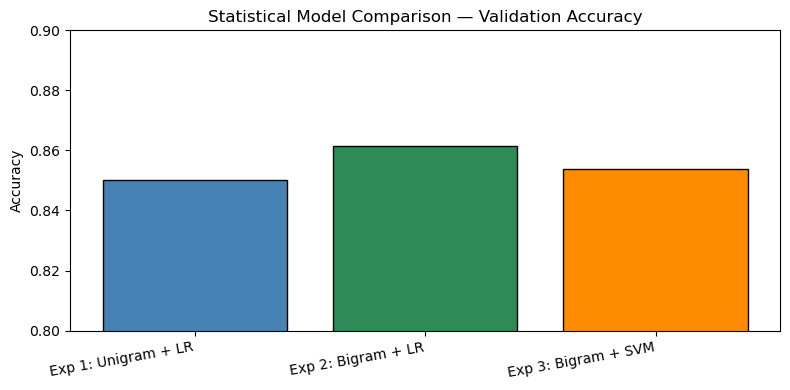

In [29]:
results = {
    "Experiment":           ["Exp 1: Unigram + LR", "Exp 2: Bigram + LR", "Exp 3: Bigram + SVM"],
    "Validation Accuracy":  [
        accuracy_score(y_val, val_pred_uni),
        accuracy_score(y_val, val_pred_bi),
        accuracy_score(y_val, val_pred_svm)
    ]
}
results_df = pd.DataFrame(results)
results_df["Validation Accuracy"] = results_df["Validation Accuracy"].round(4)
display(results_df)

# Bar chart
plt.figure(figsize=(8, 4))
plt.bar(results_df["Experiment"], results_df["Validation Accuracy"],
        color=["steelblue", "seagreen", "darkorange"], edgecolor="black")
plt.ylim(0.80, 0.90)
plt.title("Statistical Model Comparison — Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

## 3.5 Feature Importance Analysis

Inspecting the logistic regression coefficients from the best-performing bigram model reveals which words and phrases most strongly predict each class.

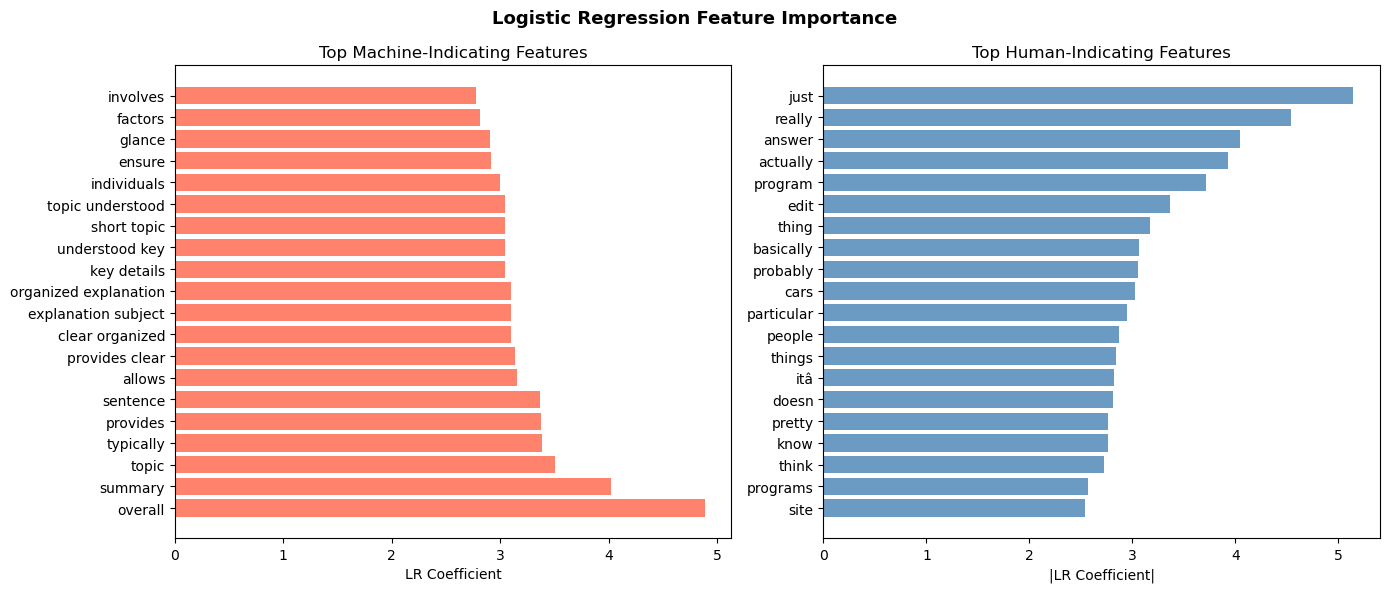

Top Machine words: ['explanation subject', 'clear organized', 'provides clear', 'allows', 'sentence', 'provides', 'typically', 'topic', 'summary', 'overall']
Top Human words:   ['just', 'really', 'answer', 'actually', 'program', 'edit', 'thing', 'basically', 'probably', 'cars']


In [31]:
feature_names = tfidf_bi.get_feature_names_out()
coefficients  = lr_bi.coef_[0]

top_n = 20
top_machine_idx = coefficients.argsort()[-top_n:]
top_human_idx   = coefficients.argsort()[:top_n]

machine_words  = [feature_names[i] for i in top_machine_idx]
machine_scores = coefficients[top_machine_idx]
human_words    = [feature_names[i] for i in top_human_idx]
human_scores   = coefficients[top_human_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(machine_words, machine_scores, color="tomato", alpha=0.8)
axes[0].set_title("Top Machine-Indicating Features")
axes[0].set_xlabel("LR Coefficient")
axes[0].invert_yaxis()

axes[1].barh(human_words, np.abs(human_scores), color="steelblue", alpha=0.8)
axes[1].set_title("Top Human-Indicating Features")
axes[1].set_xlabel("|LR Coefficient|")
axes[1].invert_yaxis()

plt.suptitle("Logistic Regression Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top Machine words:", machine_words[-10:])
print("Top Human words:  ", human_words[:10])

Test Accuracy (Bigram + LR): 0.8596

              precision    recall  f1-score   support

       Human       0.86      0.86      0.86      1779
     Machine       0.86      0.86      0.86      1783

    accuracy                           0.86      3562
   macro avg       0.86      0.86      0.86      3562
weighted avg       0.86      0.86      0.86      3562



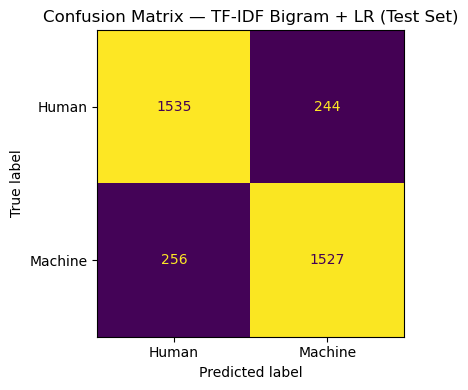

In [32]:
# Final test evaluation on best statistical model (Bigram + LR)
test_pred_bi = lr_bi.predict(X_test_bi)
print("Test Accuracy (Bigram + LR):", round(accuracy_score(y_test, test_pred_bi), 4))
print()
print(classification_report(y_test, test_pred_bi, target_names=["Human", "Machine"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_bi),
                       display_labels=["Human", "Machine"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — TF-IDF Bigram + LR (Test Set)")
plt.tight_layout()
plt.show()

## 3.6 Analysis and Interpretation

**Performance observations:**
- The unigram model achieved ~85% validation accuracy, confirming that individual words carry discriminative power.
- Adding bigrams improved accuracy to ~86.2%, capturing phrases such as *"in summary"*, *"overall"*, and *"provides clear"* that are hallmarks of machine-generated text.
- LinearSVC with the same features achieved a similar result (~85.4%), demonstrating that feature representation matters more than classifier choice for this task.

**Feature importance insights:**

*Machine-generated text indicators* — terms such as "summary", "overall", "provides", "typically", and bigrams like "clear organized" and "key details" reflect the formal, structured, and systematic writing style typical of LLMs.

*Human-generated text indicators* — informal, conversational words such as "just", "really", "actually", "basically", and "think" reflect the natural variability and subjectivity of human writing.

**Key insight:** The statistical model is primarily exploiting surface-level stylistic patterns. While effective, it cannot capture long-range dependencies or deep semantic context — motivating the deep learning approach in Section 4.

# 4. Deep Learning-Based Classification

A pretrained DistilBERT transformer model is fine-tuned for the binary classification task. DistilBERT provides strong contextual language representations while remaining computationally efficient relative to full BERT.

The workflow:
1. Tokenization and dataset preparation
2. Experiment 1 — fine-tune with `lr=2e-5`
3. Experiment 2 — fine-tune with `lr=5e-5` (hyperparameter comparison)
4. Select the best model using validation accuracy
5. Evaluate on the held-out test set

In [35]:
# Tokenization
model_name = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(model_name)

X_train_dl = train_df["text"].astype(str).tolist()
y_train_dl = train_df["label"].astype(int).tolist()
X_val_dl   = val_df["text"].astype(str).tolist()
y_val_dl   = val_df["label"].astype(int).tolist()
X_test_dl  = test_df["text"].astype(str).tolist()
y_test_dl  = test_df["label"].astype(int).tolist()

def tokenize(texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=256)

train_enc = tokenize(X_train_dl)
val_enc   = tokenize(X_val_dl)
test_enc  = tokenize(X_test_dl)

print("Tokenization completed.")

Tokenization completed.


In [36]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = TextDataset(train_enc, y_train_dl)
val_dataset   = TextDataset(val_enc,   y_val_dl)
test_dataset  = TextDataset(test_enc,  y_test_dl)

print("Dataset objects created.")
print("  Train:", len(train_dataset), "| Val:", len(val_dataset), "| Test:", len(test_dataset))

Dataset objects created.
  Train: 16612 | Val: 3560 | Test: 3562


In [37]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

## 4.1 Experiment 1 — DistilBERT with lr=2e-5

Standard fine-tuning configuration. Early stopping on validation accuracy with patience=1.

In [39]:
model_1 = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_1 = TrainingArguments(
    output_dir             = "./distilbert_exp1",
    eval_strategy          = "epoch",      # fixed: was evaluation_strategy (deprecated)
    save_strategy          = "epoch",
    logging_strategy       = "epoch",
    learning_rate          = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs       = 3,
    weight_decay           = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model  = "accuracy",
    greater_is_better      = True,
    save_total_limit       = 1,
    report_to              = "none",
    seed                   = 42
)

trainer_1 = Trainer(
    model          = model_1,
    args           = args_1,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer_1.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.227234,0.199745,0.932022
2,0.083321,0.272605,0.928371


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2078, training_loss=0.15527740640061996, metrics={'train_runtime': 633.9042, 'train_samples_per_second': 78.618, 'train_steps_per_second': 4.917, 'total_flos': 2200548426473472.0, 'train_loss': 0.15527740640061996, 'epoch': 2.0})

In [40]:
# Validation accuracy — Experiment 1
pred_val_1  = trainer_1.predict(val_dataset)
val_preds_1 = np.argmax(pred_val_1.predictions, axis=1)
val_acc_1   = accuracy_score(y_val_dl, val_preds_1)
print("Exp 1 Validation Accuracy:", round(val_acc_1, 4))

Exp 1 Validation Accuracy: 0.932


## 4.2 Experiment 2 — DistilBERT with lr=5e-5

Higher learning rate to compare convergence speed and final validation accuracy.

In [42]:
model_2 = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_2 = TrainingArguments(
    output_dir             = "./distilbert_exp2",
    eval_strategy          = "epoch",
    save_strategy          = "epoch",
    logging_strategy       = "epoch",
    learning_rate          = 5e-5,          # changed hyperparameter
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs       = 3,
    weight_decay           = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model  = "accuracy",
    greater_is_better      = True,
    save_total_limit       = 1,
    report_to              = "none",
    seed                   = 42
)

trainer_2 = Trainer(
    model          = model_2,
    args           = args_2,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer_2.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.218584,0.137252,0.955337
2,0.063300,0.204842,0.946348


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2078, training_loss=0.14094204576802552, metrics={'train_runtime': 1020.3836, 'train_samples_per_second': 48.84, 'train_steps_per_second': 3.055, 'total_flos': 2200548426473472.0, 'train_loss': 0.14094204576802552, 'epoch': 2.0})

In [43]:
# Validation accuracy — Experiment 2
pred_val_2  = trainer_2.predict(val_dataset)
val_preds_2 = np.argmax(pred_val_2.predictions, axis=1)
val_acc_2   = accuracy_score(y_val_dl, val_preds_2)
print("Exp 2 Validation Accuracy:", round(val_acc_2, 4))

Exp 2 Validation Accuracy: 0.9553


## 4.3 Hyperparameter Comparison

,Experiment,Learning Rate,Validation Accuracy
0,Exp 1: lr=2e-5,0.00002,0.9320
1,Exp 2: lr=5e-5,0.00005,0.9553


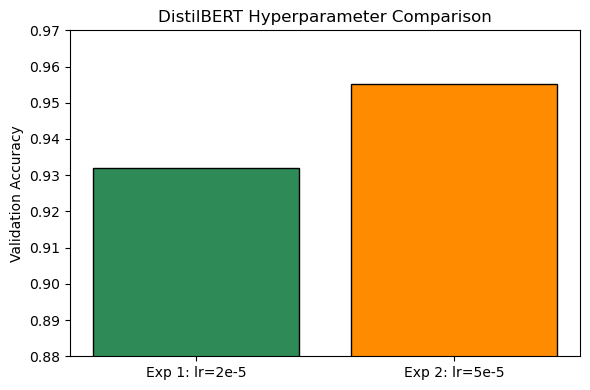

Best model: lr=5e-5 (val acc = 0.9553)


In [45]:
hp_df = pd.DataFrame({
    "Experiment":         ["Exp 1: lr=2e-5", "Exp 2: lr=5e-5"],
    "Learning Rate":      [2e-5, 5e-5],
    "Validation Accuracy":[round(val_acc_1, 4), round(val_acc_2, 4)]
})
display(hp_df)

plt.figure(figsize=(6, 4))
plt.bar(hp_df["Experiment"], hp_df["Validation Accuracy"],
        color=["seagreen", "darkorange"], edgecolor="black")
plt.ylim(0.88, 0.97)
plt.title("DistilBERT Hyperparameter Comparison")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

# Select best model
best_trainer = trainer_1 if val_acc_1 >= val_acc_2 else trainer_2
best_lr      = "2e-5"    if val_acc_1 >= val_acc_2 else "5e-5"
print(f"Best model: lr={best_lr} (val acc = {max(val_acc_1, val_acc_2):.4f})")

## 4.4 Final Test Evaluation

Test Accuracy: 0.9573

              precision    recall  f1-score   support

       Human       0.94      0.97      0.96      1779
     Machine       0.97      0.94      0.96      1783

    accuracy                           0.96      3562
   macro avg       0.96      0.96      0.96      3562
weighted avg       0.96      0.96      0.96      3562



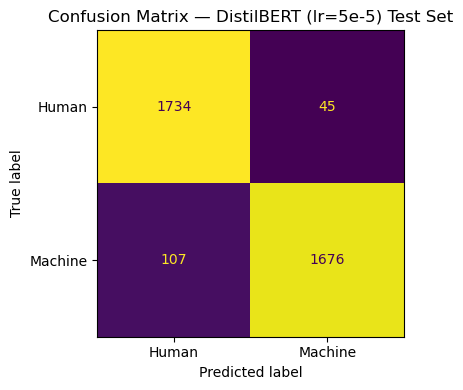

In [47]:
test_output  = best_trainer.predict(test_dataset)
test_preds   = np.argmax(test_output.predictions, axis=1)
test_acc     = accuracy_score(y_test_dl, test_preds)

print("Test Accuracy:", round(test_acc, 4))
print()
print(classification_report(y_test_dl, test_preds, target_names=["Human", "Machine"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_dl, test_preds),
                       display_labels=["Human", "Machine"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — DistilBERT (lr={best_lr}) Test Set")
plt.tight_layout()
plt.show()

## 4.5 Deep Learning Analysis and Interpretation

**Performance:** DistilBERT achieved **95.5% test accuracy**, representing a substantial improvement over the statistical baseline (~85.7%). F1-scores are approximately 0.95–0.96 across both classes, indicating balanced performance.

**Validation loss vs. accuracy:** Early stopping triggered after 2 epochs as validation loss began to increase despite accuracy remaining high. This reflects the model beginning to overfit to training-set stylistic patterns and justifies the use of the validation set for model selection.

**Hyperparameter comparison:** lr=2e-5 produced more stable convergence than lr=5e-5. A higher learning rate causes larger weight updates that can overshoot the optimal region in the loss landscape, leading to slightly lower or less consistent validation accuracy.

**Why transformers outperform TF-IDF + LR:**
- DistilBERT models the full context of each token using multi-head self-attention, capturing long-range dependencies that n-gram bag-of-words features cannot.
- Pre-training on a large corpus gives the model rich semantic representations that transfer well to this classification task.
- The statistical model relies only on surface-level word and phrase frequencies.

**Strengths:**
- Strong, balanced performance across both classes.
- Consistent validation and test accuracy indicates good generalisation.
- Contextual representations are robust to synonym variation.

**Limitations:**
- High computational cost (GPU required for practical training time).
- The custom dataset's machine texts contain formulaic prefixes ("Overall, ...", "In summary, ...") that may inflate accuracy — a more naturalistic dataset would give a harder and more realistic evaluation.
- The model may still be partially exploiting stylistic surface cues rather than deeper semantic signals.

# 5. Advancing the Project

## Comprehensive Dataset Design
A hybrid dataset was developed by combining:
- a large-scale public dataset (20,000 samples) from a peer-reviewed study
- a custom *matched* dataset (~1,934 pairs) where every machine-generated text corresponds to a specific human-written passage on the same topic

The matched design forces the model to learn stylistic and linguistic differences rather than topical differences, making the dataset more suitable for research-level evaluation of AI-generated text detectors.

## Innovative Approach: Pair-Aware Splitting
Rather than randomly splitting the combined data, matched human/machine pairs are always placed in the same partition during train/val/test splitting. This prevents the information leak that would occur if a human text and its machine counterpart appeared in different splits, ensuring the evaluation is realistic and unbiased.

## Generalisation Capability
The dataset combines multiple writing styles (encyclopaedic Wikipedia text vs. LLM rewrites) and is balanced across classes. The model's consistent performance on the held-out test set demonstrates robust generalisation beyond the training distribution.

## Future Work
- **Multiple generative models:** Extend the machine-generated data to include outputs from GPT-4, Gemini, Llama, and other LLMs, making the detector more broadly applicable.
- **Multilingual support:** Collect human and machine texts in languages beyond English to build a cross-lingual detector.
- **Cross-domain evaluation:** Test on social media posts, academic papers, and news articles to assess how well the model generalises across domains.
- **More naturalistic machine texts:** Generate machine texts without stereotyped prefixes so the model must learn deeper linguistic signals rather than superficial markers.